**Import Libraries**

In [ ]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Explainable AI
import shap

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

**Load Dataset**

In [ ]:
import os
import pandas as pd
import kagglehub

# Load dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

# Assuming the dataset is a CSV file within the downloaded path
# Look for a .csv file in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    data = pd.read_csv(csv_file_path)
else:
    print("No CSV file found in the downloaded dataset directory.")
    data = None # Or handle the error appropriately

# View first 5 rows if data was loaded successfully
if data is not None:
    data.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.


**Data Understanding**

In [ ]:
# Dataset shape
data.shape

# Data types
data.info()

# Check missing values
data.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Data Cleaning**

In [ ]:
# Remove customer ID (not useful for prediction)
data.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")

# Fill missing values with median
data["TotalCharges"].fillna(data["TotalCharges"].median(), inplace=True)

# Convert target variable
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})


**Feature Encoding**

In [ ]:
# One-hot encode categorical features
data_encoded = pd.get_dummies(data, drop_first=True)

data_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


**Train–Test Split**

In [ ]:
# Separate features and target
X = data_encoded.drop("Churn", axis=1)
y = data_encoded["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


**Baseline Model (Logistic Regression)**

In [ ]:
# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)

# Evaluation
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))


Logistic Regression Results
Accuracy: 0.8034066713981547
Precision: 0.6520376175548589
Recall: 0.5561497326203209
F1-score: 0.6002886002886003


**Final Model (XGBoost)**

In [ ]:
# Train XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))


XGBoost Results
Accuracy: 0.7906316536550745
Precision: 0.6246056782334385
Recall: 0.5294117647058824
F1-score: 0.573082489146165
ROC-AUC: 0.8341561393991062


**Explainable AI (SHAP – CORE SECTION)**

In [ ]:
X_train.dtypes[X_train.dtypes == "object"]


,0


In [ ]:
# Ensure all features are numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)


In [ ]:
# Initialize SHAP explainer
explainer = shap.Explainer(xgb_model, X_train)

# Calculate SHAP values
shap_values = explainer(X_test)


 91%|==================  | 1288/1409 [00:12<00:01]       

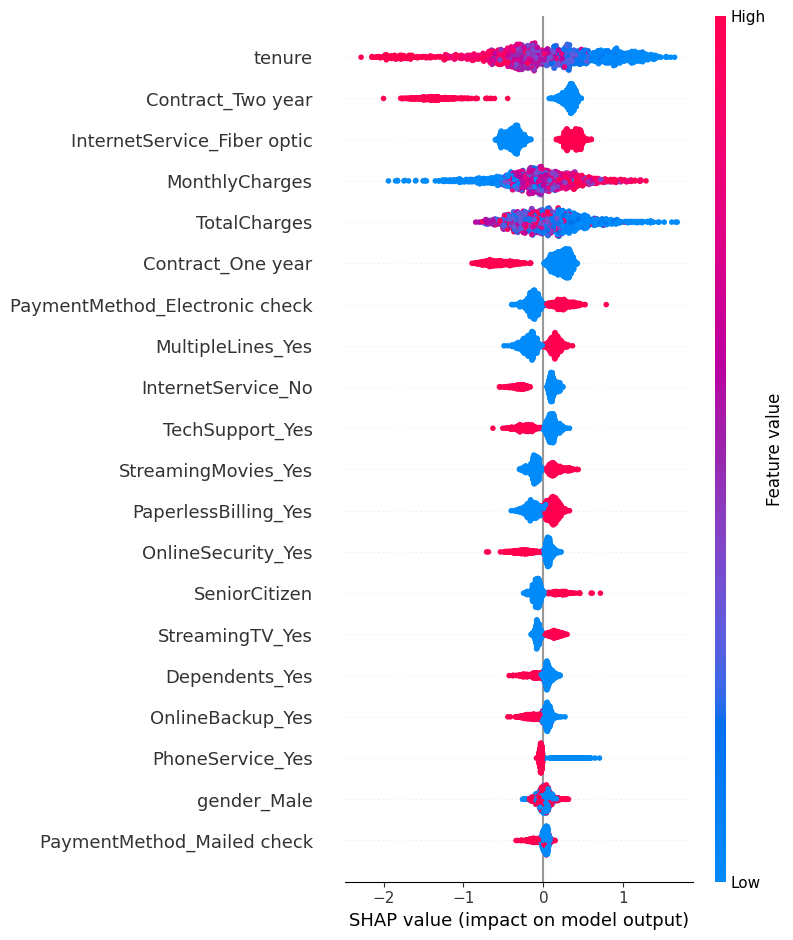

In [ ]:
# SHAP summary plot
shap.summary_plot(shap_values, X_test)


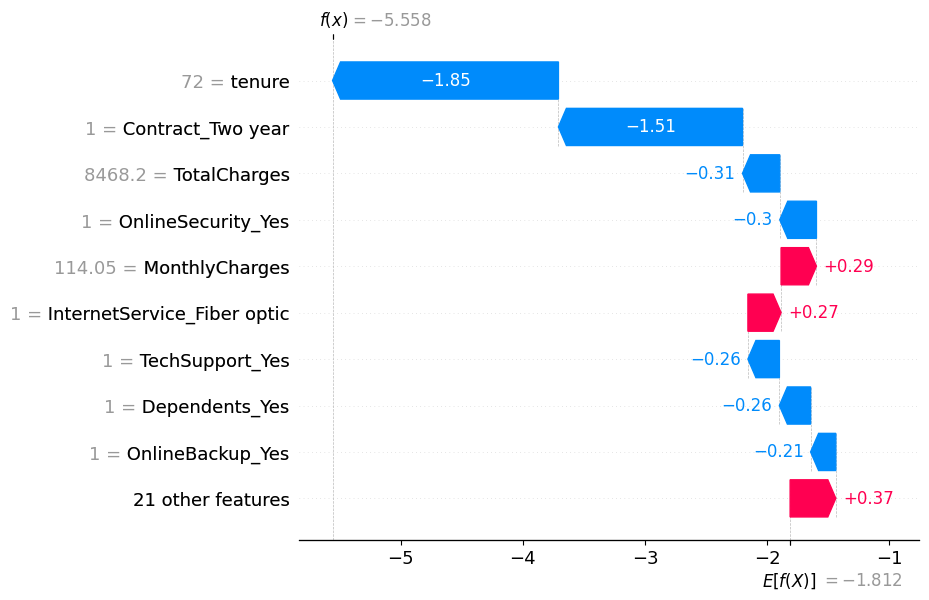

In [ ]:
# Explain one customer prediction
shap.plots.waterfall(shap_values[0])


**Business Insights (CRUCIAL)**

### Business Insights Derived from Explainable AI

- Customers with month-to-month contracts show higher churn risk
- High monthly charges significantly increase churn probability
- Low tenure customers are more likely to leave early

**Recommended Actions:**
- Promote long-term contracts
- Offer personalized discounts
- Improve onboarding experience
